import numpy as np
import pandas as pd
import matplotlib
import sklearn
import scipy
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import scipy

print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Matplotlib:   {matplotlib.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"SciPy:        {scipy.__version__}")

NumPy:        2.5.3
Pandas:       3.0.5
Matplotlib:   3.11.2
Scikit-learn: 1.9.1
SciPy:        1.18.1


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
n = 300
hora = np.random.randint(0, 24, n)
monto = np.random.exponential(scale=150, size=n) + 10
# Fraude mas probable de madrugada (0-5h, 23h) y en montos altos
prob_fraude = 0.03 + 0.35 * ((hora <= 5) | (hora >= 23)) + 0.25 * (monto > 400)
prob_fraude = np.clip(prob_fraude, 0, 0.9)
es_fraude = (np.random.rand(n) < prob_fraude).astype(int)
transacciones = pd.DataFrame({"hora": hora, "monto": monto, "es_fraude": es_fraude})
colores = {0: "#0ca30c", 1: "#d03b3b"} # verde = legitima, rojo = fraude
etiquetas = {0: "Legitima", 1: "Fraude"}
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for valor in [0, 1]:
    subset = transacciones[transacciones["es_fraude"] == valor]
    ax.scatter(
        subset["hora"], subset["monto"],
        s=70, alpha=0.75,
        c=colores[valor],
        edgecolors="white", linewidths=0.6,
        label=etiquetas[valor],
    )
ax.set_title("Transacciones por hora y monto", fontsize=15, color="#0b0b0b", pad=14)
ax.set_xlabel("Hora del dia", fontsize=11, color="#52514e")
ax.set_ylabel("Monto (S/)", fontsize=11, color="#52514e")
ax.set_xticks(range(0, 24, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Tipo de transaccion", frameon=False, loc="upper right")
plt.tight_layout()
plt.show()
print("Total transacciones:", len(transacciones),
    "| Fraudes:", transacciones["es_fraude"].sum())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
n = 300
hora = np.random.randint(0, 24, n)
monto = np.random.exponential(scale=150, size=n) + 10
# Fraude mas probable de madrugada (0-5h, 23h) y en montos altos
prob_fraude = 0.03 + 0.35 * ((hora <= 5) | (hora >= 23)) + 0.25 * (monto > 400)
prob_fraude = np.clip(prob_fraude, 0, 0.9)
es_fraude = (np.random.rand(n) < prob_fraude).astype(int)
transacciones = pd.DataFrame({"hora": hora, "monto": monto, "es_fraude": es_fraude})
colores = {0: "#0ca30c", 1: "#d03b3b"} # verde = legitima, rojo = fraude
etiquetas = {0: "Legitima", 1: "Fraude"}
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for valor in [0, 1]:
    subset = transacciones[transacciones["es_fraude"] == valor]
    ax.scatter(
        subset["hora"], subset["monto"],s=70, alpha=0.75,
        c=colores[valor],
        edgecolors="white", linewidths=0.6,
        label=etiquetas[valor],
        )
ax.set_title("Transacciones por hora y monto", fontsize=15, color="#0b0b0b", pad=14)
ax.set_xlabel("Hora del dia", fontsize=11, color="#52514e")
ax.set_ylabel("Monto (S/)", fontsize=11, color="#52514e")
ax.set_xticks(range(0, 24, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Tipo de transaccion", frameon=False, loc="upper right")
plt.tight_layout()
plt.show()
print("Total transacciones:", len(transacciones),
"| Fraudes:", transacciones["es_fraude"].sum())

### 1. Simulación del Comportamiento Transaccional
importamos las librerías necesarias y generamos una muestra sintética de n=300 transacciones.
* **Hora:** Variable discreta uniforme entre 0 y 23 horas.
* **Monto:** Variable continua para reflejar que la gran mayoría de pagos son pequeños, mientras que los montos altos son excepcionales.
* **np.random.seed(42):** Garantiza la reproducibilidad del experimento.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

hora = np.random.randint(0, 24, n)
monto = np.random.exponential(scale=150, size=n) + 10

### 2. Generación de la Variable Objetivo que será `es_fraude`
Definimos las etiquetas mediante una función de probabilidad condicional con base en dos factores de riesgo:
* **Probabilidad base:** 3% para cualquier transacción normal.
* **Penalización horaria:** Suma 35% de probabilidad si la transacción ocurre de madrugada entre 23:00 y 05:00 h
* **Penalización por monto:** Suma 25% de probabilidad si el monto excede los S/ 400.
* **Restricción:** Se limita la probabilidad máxima al 90% con `np.clip`.

Posteriormente, se simula el resultado mediante un ensayo de Bernoulli comparando con valores aleatorios uniformes y
se consolida todo

In [4]:
# Fraude mas probable de madrugada (0-5h, 23h) y en montos altos
prob_fraude = 0.03 + 0.35 * ((hora <= 5) | (hora >= 23)) + 0.25 * (monto > 400)
prob_fraude = np.clip(prob_fraude, 0, 0.9)
es_fraude = (np.random.rand(n) < prob_fraude).astype(int)

transacciones = pd.DataFrame(
    {"hora": hora, "monto": monto, "es_fraude": es_fraude}
)
transacciones.head()

,hora,monto,es_fraude
0,6,99.246385,0
1,19,789.295431,0
2,14,39.024106,0
3,10,12.736108,0
4,7,112.151287,0


### 3. Análisis Visual y Resumen
Se grafica un diagrama de dispersión separando las operaciones legítimas (color verde) de los fraudes (color rojo). 

El objetivo visual es identificar la correlación espacial entre el horario, el importe transferido y la incidencia de operaciones fraudulentas.

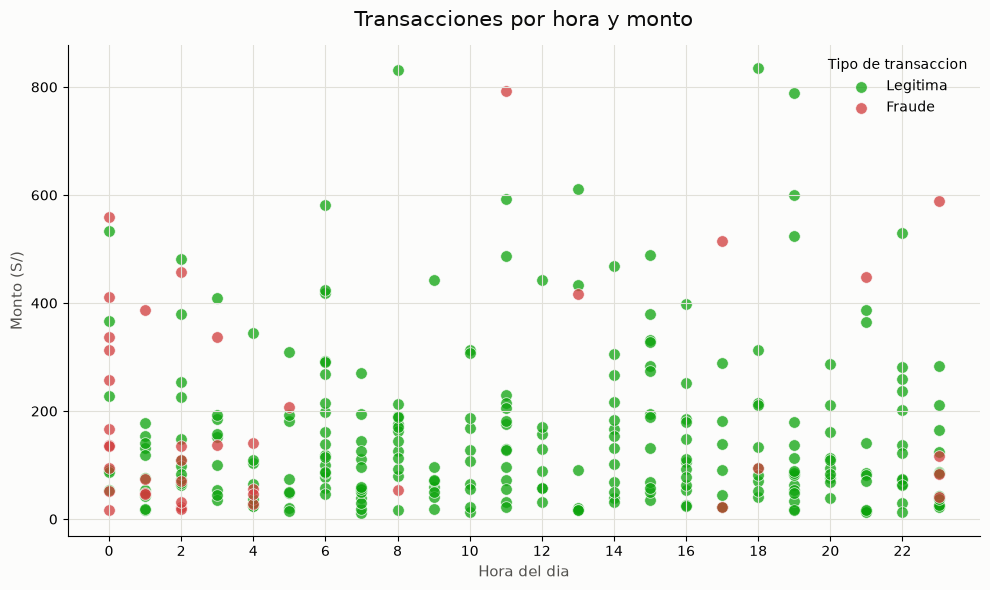

Total transacciones: 300 | Fraudes: 40


In [5]:
colores = {0: "#0ca30c", 1: "#d03b3b"}  # verde = legitima, rojo = fraude
etiquetas = {0: "Legitima", 1: "Fraude"}

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for valor in [0, 1]:
    subset = transacciones[transacciones["es_fraude"] == valor]
    ax.scatter(
        subset["hora"],
        subset["monto"],
        s=70,
        alpha=0.75,
        c=colores[valor],
        edgecolors="white",
        linewidths=0.6,
        label=etiquetas[valor],
    )

ax.set_title(
    "Transacciones por hora y monto", fontsize=15, color="#0b0b0b", pad=14
)
ax.set_xlabel("Hora del dia", fontsize=11, color="#52514e")
ax.set_ylabel("Monto (S/)", fontsize=11, color="#52514e")
ax.set_xticks(range(0, 24, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Tipo de transaccion", frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

print(
    "Total transacciones:",
    len(transacciones),
    "| Fraudes:",
    transacciones["es_fraude"].sum(),
)